<a href="https://colab.research.google.com/github/Nilaoli/PythonLearningProject/blob/main/Uber_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [28]:
ddf=pd.read_csv('/content/UberDataset.csv')

In [29]:
ddf.head(1156)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


In [30]:
from datetime import datetime

format="%d/%m/%Y %H:%M"

for i in ddf['START_DATE']:
    print(datetime.strptime(i, format))

ValueError: time data '01-01-2016 21:11' does not match format '%d/%m/%Y %H:%M'

In [31]:
ddf.isnull().sum()

,0
START_DATE,0
END_DATE,1
CATEGORY,1
START,1
STOP,1
MILES,0
PURPOSE,503


In [32]:
ddf.duplicated().sum()

np.int64(1)

In [33]:
ddf.nunique()

,0
START_DATE,1155
END_DATE,1154
CATEGORY,2
START,177
STOP,188
MILES,257
PURPOSE,10


In [34]:
ddf['PURPOSE'].value_counts()

,count
PURPOSE,
Meeting,187
Meal/Entertain,160
Errand/Supplies,128
Customer Visit,101
Temporary Site,50
Between Offices,18
Moving,4
Airport/Travel,3
Commute,1


In [35]:

ddf['PURPOSE'] = ddf['PURPOSE'].fillna('ffill')
ddf.head(25)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,ffill
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
5,01-06-2016 17:15,01-06-2016 17:19,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain
6,01-06-2016 17:30,01-06-2016 17:35,Business,West Palm Beach,Palm Beach,7.1,Meeting
7,01-07-2016 13:27,01-07-2016 13:33,Business,Cary,Cary,0.8,Meeting
8,01-10-2016 08:05,01-10-2016 08:25,Business,Cary,Morrisville,8.3,Meeting
9,01-10-2016 12:17,01-10-2016 12:44,Business,Jamaica,New York,16.5,Customer Visit


In [36]:
ddf['START_DATE'] = pd.to_datetime(ddf['START_DATE'],format='mixed', errors='coerce')
ddf['END_DATE'] = pd.to_datetime(ddf['END_DATE'],format='mixed',errors='coerce')

In [37]:
ddf.head(25)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,ffill
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
5,2016-01-06 17:15:00,2016-01-06 17:19:00,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain
6,2016-01-06 17:30:00,2016-01-06 17:35:00,Business,West Palm Beach,Palm Beach,7.1,Meeting
7,2016-01-07 13:27:00,2016-01-07 13:33:00,Business,Cary,Cary,0.8,Meeting
8,2016-01-10 08:05:00,2016-01-10 08:25:00,Business,Cary,Morrisville,8.3,Meeting
9,2016-01-10 12:17:00,2016-01-10 12:44:00,Business,Jamaica,New York,16.5,Customer Visit


In [38]:
ddf['start_date'] = ddf['START_DATE'].dt.date
ddf['start_time'] = ddf['START_DATE'].dt.time
ddf['end_date'] = ddf['END_DATE'].dt.date
ddf['end_time'] = ddf['END_DATE'].dt.time
ddf['month'] = ddf['START_DATE'].dt.month
ddf['year'] = ddf['START_DATE'].dt.year

In [39]:
ddf.head(25)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,start_date,start_time,end_date,end_time,month,year
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21:11:00,2016-01-01,21:17:00,1.0,2016.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,ffill,2016-01-02,01:25:00,2016-01-02,01:37:00,1.0,2016.0
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20:25:00,2016-01-02,20:38:00,1.0,2016.0
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17:31:00,2016-01-05,17:45:00,1.0,2016.0
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14:42:00,2016-01-06,15:49:00,1.0,2016.0
5,2016-01-06 17:15:00,2016-01-06 17:19:00,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,2016-01-06,17:15:00,2016-01-06,17:19:00,1.0,2016.0
6,2016-01-06 17:30:00,2016-01-06 17:35:00,Business,West Palm Beach,Palm Beach,7.1,Meeting,2016-01-06,17:30:00,2016-01-06,17:35:00,1.0,2016.0
7,2016-01-07 13:27:00,2016-01-07 13:33:00,Business,Cary,Cary,0.8,Meeting,2016-01-07,13:27:00,2016-01-07,13:33:00,1.0,2016.0
8,2016-01-10 08:05:00,2016-01-10 08:25:00,Business,Cary,Morrisville,8.3,Meeting,2016-01-10,08:05:00,2016-01-10,08:25:00,1.0,2016.0
9,2016-01-10 12:17:00,2016-01-10 12:44:00,Business,Jamaica,New York,16.5,Customer Visit,2016-01-10,12:17:00,2016-01-10,12:44:00,1.0,2016.0


In [40]:
ddf.drop(['START_DATE','END_DATE'],axis=1,inplace=True)
ddf = ddf[['start_date','start_time','end_date','end_time','month','year','CATEGORY','START','STOP','MILES','PURPOSE']]

In [41]:
ddf.month.value_counts()

,count
month,
12.0,146
8.0,133
11.0,122
2.0,115
3.0,113
7.0,112
6.0,108
10.0,106
1.0,61


In [42]:
base_fares=np.array([150, 200, 120, 300, 250])
surge_fares=base_fares*1.5

print("Base Fares: ", base_fares)
print("Surge Fares:", surge_fares)

Base Fares:  [150 200 120 300 250]
Surge Fares: [225. 300. 180. 450. 375.]


In [27]:
slow_fares=[]
for fare in base_fares:
    slow_fares.append(fare*1.5)
print("Slow Fares", slow_fares)

Slow Fares [np.float64(225.0), np.float64(300.0), np.float64(180.0), np.float64(450.0), np.float64(375.0)]


In [43]:
ratings=np.array([4.2, 3.8, 4.9, 2.1, 4.7, 3.5, 4.4])

print("Average rating:", np.mean(ratings).round(0))
print("Lowest rating:", np.min(ratings))
print("Ratings below 3:", ratings[ratings<3.0])
print("Drivers above 4.5 ratings:", np.sum(ratings>4.5))
print("Ratings above 4.0 ratings:", ratings[ratings>4.0])

Average rating: 4.0
Lowest rating: 2.1
Ratings below 3: [2.1]
Drivers above 4.5 ratings: 2
Ratings above 4.0 ratings: [4.2 4.9 4.7 4.4]


In [44]:
sampledata={
    "RideID": [101,102,103,104,105],
    "PickUp": ['Airport','City','City','Airport','Airport'],
    "Durations": [32,22,40,35,18],
    "Status": ['Completed','Cancelled','Completed','Completed','No Cars']
}

sample_df=pd.DataFrame(sampledata)

print("our first dataframe for 5 rides")
print(sample_df)
print(f"\n Shape: {sample_df.shape}       ← (rows, columns)")

our first dataframe for 5 rides
   RideID   PickUp  Durations     Status
0     101  Airport         32  Completed
1     102     City         22  Cancelled
2     103     City         40  Completed
3     104  Airport         35  Completed
4     105  Airport         18    No Cars

 Shape: (5, 4)       ← (rows, columns)


In [45]:
df=pd.read_excel('/content/UberDataset.xls')

print("✅ Uber data loaded successfully!")
print(f"\nShape: {df.shape[0]:,} rows of rides x {df.shape[1]} columns")

✅ Uber data loaded successfully!

Shape: 1,156 rows of rides x 7 columns


In [46]:
df.head(5)
df.tail(5)
df.sample(5)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
178,2016-03-03 09:45:00,2016-03-03 09:52:00,Personal,Whitebridge,Westpark Place,2.2,NaN
368,2016-11-05 21:47:00,2016-11-05 22:04:00,Business,Morrisville,Cary,8.1,Meeting
45,1/27/2016 9:24,1/27/2016 9:31,Business,Cary,Cary,1.8,Meeting
538,2016-12-07 16:10:00,2016-12-07 16:45:00,Business,New Orleans,Kenner,12.3,NaN
476,6/26/2016 19:41,6/26/2016 19:50,Business,Kenner,Kenner,2.2,NaN


In [47]:
print("━" * 55)
print("FIRST 5 ROWS — df.head()")
print("━" * 55)
df.head()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FIRST 5 ROWS — df.head()
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,2016-02-01 01:25:00,2016-02-01 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,2016-02-01 20:25:00,2016-02-01 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,2016-05-01 17:31:00,2016-05-01 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,2016-06-01 14:42:00,2016-06-01 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [48]:
print("━" * 55)
print("5 RANDOM ROWS — df.sample(5)")
print("━" * 55)
df.sample(5)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5 RANDOM ROWS — df.sample(5)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
805,10/13/2016 11:20,10/13/2016 11:58,Business,Unknown Location,Islamabad,9.8,NaN
18,2016-12-01 12:53:00,2016-12-01 13:09:00,Business,Hudson Square,Lower Manhattan,4.0,Meal/Entertain
1032,2016-09-12 12:09:00,2016-09-12 12:24:00,Business,Cary,Apex,5.1,Errand/Supplies
432,2016-12-06 20:05:00,2016-12-06 20:16:00,Business,Morrisville,Cary,4.3,Errand/Supplies
608,7/29/2016 17:27,7/29/2016 17:45,Business,Westpark Place,Whitebridge,2.2,Meal/Entertain


In [49]:
print(f"Shape : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Columns : {list(df.columns)}")
print()
print("Data types : df.dtypes")
print(df.dtypes)
print()
print("Full summary df.info()")
print(df.info())


Shape : 1,156 rows x 7 columns
Columns : ['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES', 'PURPOSE']

Data types : df.dtypes
START_DATE     object
END_DATE       object
CATEGORY       object
START          object
STOP           object
MILES         float64
PURPOSE        object
dtype: object

Full summary df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB
None


In [50]:
print("Descriptive statistics: describe()")
print()
display(df.describe())

Descriptive statistics: describe()



,MILES
count,1156.000000
mean,21.115398
std,359.299007
min,0.500000
25%,2.900000
50%,6.000000
75%,10.400000
max,12204.700000


In [51]:
print("checking missing data - df.isnull().sum()")
print()
missing=df.isnull().sum()
missing_pct=(df.isnull().sum()/len(df) * 100).round(2)
missing_df=pd.DataFrame({'Missing couunt': missing, 'Missing %': missing_pct})
print(missing_df)


checking missing data - df.isnull().sum()

            Missing couunt  Missing %
START_DATE               0       0.00
END_DATE                 1       0.09
CATEGORY                 1       0.09
START                    1       0.09
STOP                     1       0.09
MILES                    0       0.00
PURPOSE                503      43.51


In [52]:
from pandas.core.indexes import category
# ============================================================
# PANDAS STEP 7: Duplicate Check & Value Counts
# ============================================================

dup_count=df.duplicated().sum()
print(dup_count)
if dup_count==0:
    print("No duplicates found: ----! Data is clean")
else:
    df = df.drop_duplicates()
    print(f"Duplicates found and removed, New shape is {df.shape}")
print()
print("━" * 50)
print("STATUS BREAKDOWN — df['Status'].value_counts()")
print("━" * 50)
category_counts=df['CATEGORY'].value_counts()
print(category_counts)
category_pct=df['CATEGORY'].value_counts(normalize=True).mul(100).round(1)

for category, count in category_counts.items():
      pct=category_pct[category]
      bar='█' * int(pct / 2)
      print(f"{category:<15} {count:>5} ({pct}%) {bar}")
print()
personal=(category_counts.get('Personal',0))
print(f"Personal rides {personal:,} ({personal/len(df)*100:.1f}) % of all rides")
print(f"Personal rides completed: {category_counts.get('Personal',0):,}")
print()

1
Duplicates found and removed, New shape is (1155, 7)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STATUS BREAKDOWN — df['Status'].value_counts()
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CATEGORY
Business    1077
Personal      77
Name: count, dtype: int64
Business         1077 (93.3%) ██████████████████████████████████████████████
Personal           77 (6.7%) ███

Personal rides 77 (6.7) % of all rides
Personal rides completed: 77



In [53]:
# ============================================================
# PANDAS STEP 8: Filtering Rows
# ============================================================
# SYNTAX: df[ df['column'] == 'value' ]
# ANALOGY: Like using Filter in Excel to show only certain rows
#
# Multiple conditions:
#   AND → use  &  (always wrap each condition in parentheses!)
#   OR  → use  |

business_rides=df[df['CATEGORY']== 'Business']
meet_purpose_rides=df[df['PURPOSE']== 'Meeting']
print(f"Business Rides: {len(business_rides):,}")
print(f"Meeting Purpose Rides: {len(meet_purpose_rides):,}")

missing_business_purpose=df[(df['CATEGORY']=='Business' ) & (df['PURPOSE'].isnull())]
missing_personal_purpose=df[(df['CATEGORY']=='Personal' ) & (df['PURPOSE'].isnull())]

print()
print(f"Missing Business Purpose: {len(missing_business_purpose):,}")
print(f"Missing Personal Purpose: {len(missing_personal_purpose):,}")
print()
ratio=len(missing_personal_purpose)/max(len(missing_business_purpose),1)
print(f"Missing Personal purpose are the {ratio:.1f}x higher than Missing Business purpose")


Business Rides: 1,077
Meeting Purpose Rides: 186

Missing Business Purpose: 431
Missing Personal Purpose: 71

Missing Personal purpose are the 0.2x higher than Missing Business purpose


In [54]:
# ============================================================
# FEATURE ENG STEP 2: Extract Hour from Timestamp
# ============================================================
# .dt.hour → extracts just the hour (0–23) from a datetime column
#
# "2016-11-07 14:35:22"
#       ↓  .dt.hour
#       14   ← just the hour!
from datetime import datetime
df['START_DATE']=pd.to_datetime(df['START_DATE'], format='mixed', errors='coerce')
df['END_DATE']=pd.to_datetime(df['END_DATE'], format='mixed', errors='coerce')

df['start_hr']=df['START_DATE'].dt.hour

print("Extracted hour from the timestamp")
print("Sample values:", list(df['start_hr'].head(8)))
print("All data hour in the data:", sorted(df['start_hr'].unique()))

df.info()

Extracted hour from the timestamp
Sample values: [21.0, 1.0, 20.0, 17.0, 14.0, 17.0, 17.0, 13.0]
All data hour in the data: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(nan)]
<class 'pandas.core.frame.DataFrame'>
Index: 1155 entries, 0 to 1155
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   START_DATE  1154 non-null   datetime64[ns]
 1   END_DATE    1154 non-null   datetime64[ns]
 2   CATEGORY    1154 non-null   object        
 3   START       1154 non-null   object        
 4   STOP        1154 non-null   object        
 5   MILES      

In [55]:
# ============================================================
# FEATURE ENG STEP 3: Create Time Slots
# ============================================================
# Group 24 hours into named periods for pattern recognition.
#
# Excel equivalent:
# =IF(A1<=4,"Dawn",IF(A1<=9,"Early Morning",IF(A1<=16,"Noon",...)))
#
# .apply(function) → calls the function for EVERY row

def assign_timeslot(hour):
    if hour < 4.0 : return "Dawn"
    elif hour < 9.0 : return "Early Morning"
    elif hour < 16.0 : return "Noon"
    elif hour < 21.0 : return "Late Evening"
    else: return "Night"

df['TimeSlot']= df['start_hr'].apply(assign_timeslot)
print("Time Slot Distribution")
ts=df['TimeSlot'].value_counts()
for slot , count in ts.items():
    print(f"{slot:<15} : {count:,} rides")

Time Slot Distribution
Noon            : 546 rides
Late Evening    : 416 rides
Night           : 108 rides
Early Morning   : 56 rides
Dawn            : 29 rides


In [56]:
from types import NoneType
from contextlib import nullcontext
# ============================================================
# FEATURE ENG STEP 4: Purpose Availability Flag
# ============================================================
# Simplify Status to binary: Did supply meet demand?
#   Trip Completed  → "Available"
#   Everything else → "Not Available"

df['purpose_availability']=df['PURPOSE'].apply(
    lambda x: "Not Available" if pd.isnull(x) else "Available"
)

print("Purpose Availability Breakdown")
avail=df['purpose_availability'].value_counts()
print(avail)
avail_pct=df['purpose_availability'].value_counts(normalize=True).mul(100).round(1)
for cat, count in avail.items():
    print(f" {cat:<15} : {count:,} ({avail_pct[cat]}%)")
print()

df.head()


Purpose Availability Breakdown
purpose_availability
Available        652
Not Available    503
Name: count, dtype: int64
 Available       : 652 (56.5%)
 Not Available   : 503 (43.5%)



,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,start_hr,TimeSlot,purpose_availability
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.0,Night,Available
1,2016-02-01 01:25:00,2016-02-01 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NaN,1.0,Dawn,Not Available
2,2016-02-01 20:25:00,2016-02-01 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,20.0,Late Evening,Available
3,2016-05-01 17:31:00,2016-05-01 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,17.0,Late Evening,Available
4,2016-06-01 14:42:00,2016-06-01 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,14.0,Noon,Available


In [57]:
# ============================================================
# FEATURE ENG STEP 5: Ride Duration in Minutes
# ============================================================
# Drop timestamp − Request timestamp = ride duration
# Only possible for COMPLETED rides (others have no drop time)
df.at[540, 'START_DATE'] = '2016-07-12 23:47:00'
completed = df.copy()
completed['Duration_mins']=(
    (completed['END_DATE'] - completed['START_DATE']).dt.total_seconds()/60
  )
print("⏱️  Ride Duration Statistics (completed rides only):")
print(completed['Duration_mins'].describe().round(2))

median_dur = completed['Duration_mins'].median()
print(f"💡 The median ride is {median_dur:.0f} minutes — a big time commitment for drivers.")
print("   No wonder they prefer shorter city rides over airport trips!")

⏱️  Ride Duration Statistics (completed rides only):
count     1154.00
mean       316.48
std       3513.70
min          0.00
25%         10.00
50%         17.00
75%         28.00
max      43223.00
Name: Duration_mins, dtype: float64
💡 The median ride is 17 minutes — a big time commitment for drivers.
   No wonder they prefer shorter city rides over airport trips!


In [58]:
np.set_printoptions(suppress=True)
##print(completed['Duration_mins'].unique())
##completed[(completed['Duration_mins'] > 330) | (completed['Duration_mins'] < 0)]
completed[(completed['Duration_mins'] < 0)]


completed.at[540, 'START_DATE'] = '2016-07-12 23:47:00'
completed.loc[completed['Duration_mins']<0 ,'Duration_mins']=(completed['END_DATE'] - completed['START_DATE']).dt.total_seconds()/60
##print(completed['Duration_mins'])



In [59]:
# Preview the enriched dataset
print("📋 Enriched dataset — first 8 rows:")
completed[['START_DATE', 'START', 'CATEGORY',
    'start_hr', 'TimeSlot', 'purpose_availability']].head(8)

📋 Enriched dataset — first 8 rows:


,START_DATE,START,CATEGORY,start_hr,TimeSlot,purpose_availability
0,2016-01-01 21:11:00,Fort Pierce,Business,21.0,Night,Available
1,2016-02-01 01:25:00,Fort Pierce,Business,1.0,Dawn,Not Available
2,2016-02-01 20:25:00,Fort Pierce,Business,20.0,Late Evening,Available
3,2016-05-01 17:31:00,Fort Pierce,Business,17.0,Late Evening,Available
4,2016-06-01 14:42:00,Fort Pierce,Business,14.0,Noon,Available
5,2016-06-01 17:15:00,West Palm Beach,Business,17.0,Late Evening,Available
6,2016-06-01 17:30:00,West Palm Beach,Business,17.0,Late Evening,Available
7,2016-07-01 13:27:00,Cary,Business,13.0,Noon,Available


purpose_availability
Available        652
Not Available    503
Name: count, dtype: int64


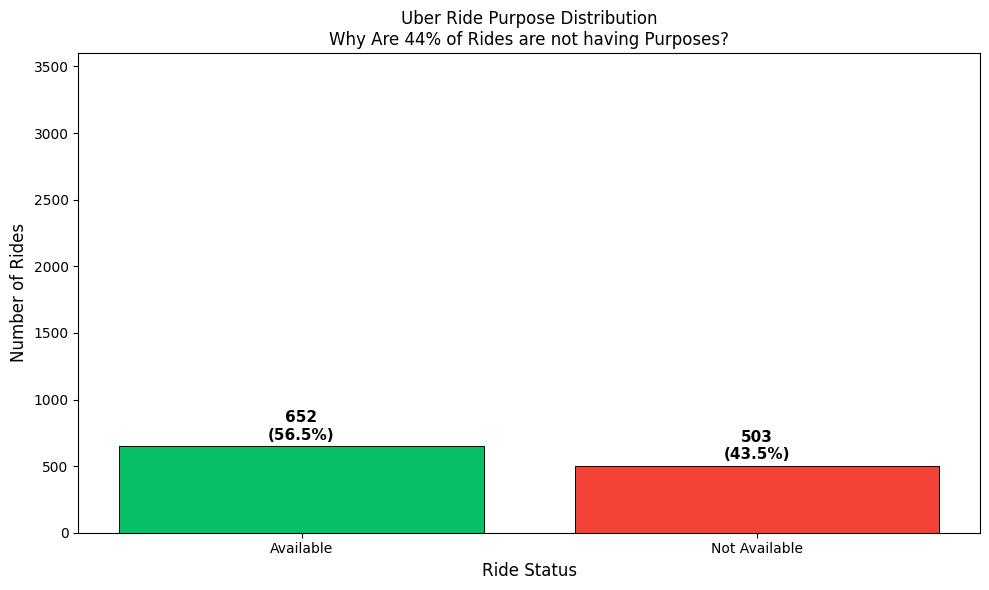

In [60]:
# ============================================================
# CHART 1: Bar Chart — Ride Purpose Distribution
# ============================================================
# QUESTION: "What percentage of rides are actually having purpose?"

purpose_data = df['purpose_availability'].value_counts()
print(purpose_data)

fig, ax =plt.subplots(figsize=(10,6))

bars=ax.bar(
    purpose_data.index,
    purpose_data.values,
    color=['#06C167', '#F44336', '#FF9800'],
    edgecolor='black',
    linewidth=0.7
)
# Value labels ON TOP of each bar
for bar in bars:
    height=bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2., height + 25,
        f'{int(height):,}\n({height/len(df)*100:.1f}%)',
        ha='center', va='bottom', fontweight='bold', fontsize=11
    )
ax.set_title('Uber Ride Purpose Distribution\nWhy Are 44% of Rides are not having Purposes?')
ax.set_xlabel('Ride Status', fontsize=12)
ax.set_ylabel('Number of Rides', fontsize=12)
ax.set_ylim(0, 3600)
plt.tight_layout()
plt.show()


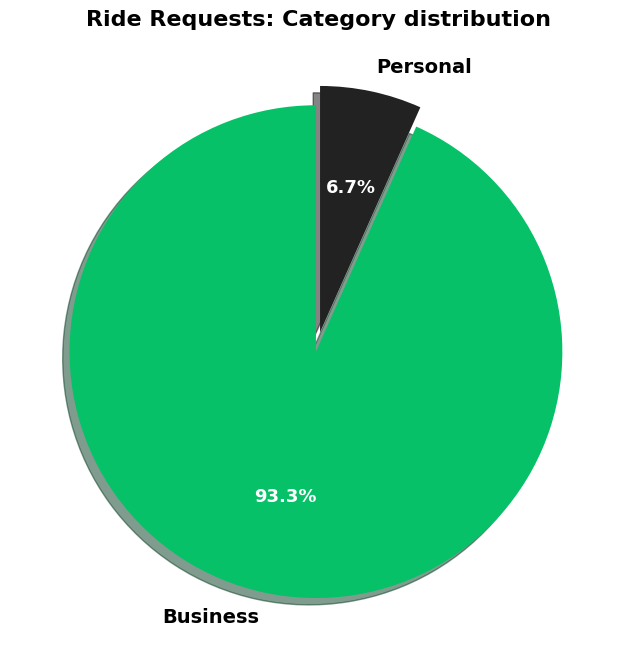

In [61]:
# ============================================================
# CHART 2: Pie Chart — Category Split
# ============================================================
# QUESTION: "Is the problem equally bad at both categories?"

category_data=df['CATEGORY'].value_counts()

fig, ax = plt.subplots(figsize=(8,8))
wedges, texts, autotexts = ax.pie(
    category_data.values,
    labels=category_data.index,
    autopct='%1.1f%%',
    colors=['#06C167', '#222222'],
    startangle=90,
    explode=[0.04, 0.04],
    shadow=True
    )
for text in texts:
    text.set_fontsize(14); text.set_fontweight('bold')
for at in autotexts:
    at.set_fontsize(13); at.set_color('white'); at.set_fontweight('bold')
ax.set_title('Ride Requests: Category distribution', fontsize=16, fontweight='bold')

plt.tight_layout
plt.show()

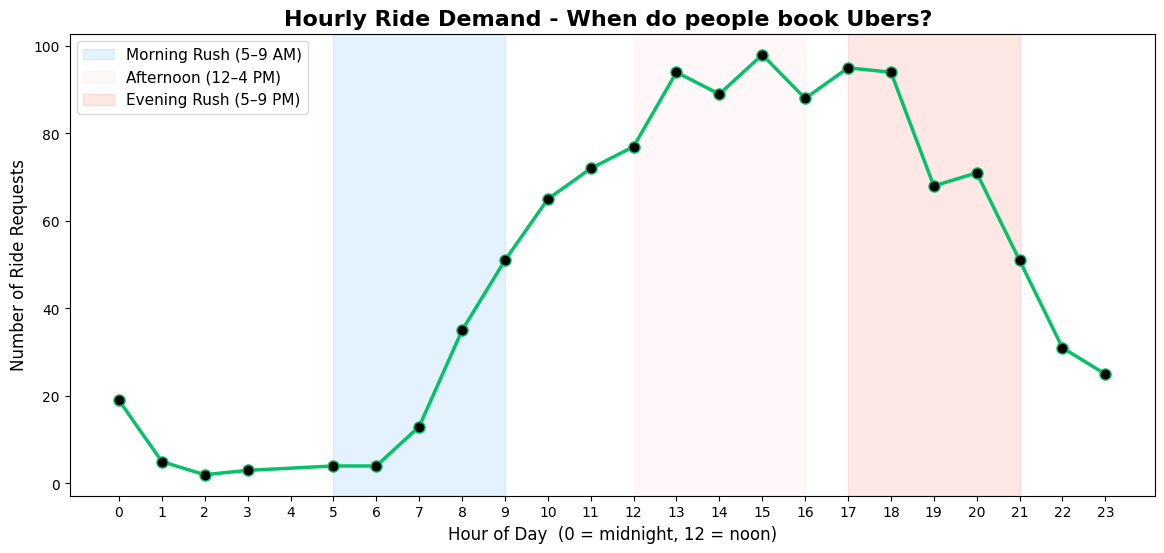

In [62]:
# ============================================================
# CHART 3: Line Chart — Hourly Demand Trend
# ============================================================
# QUESTION: "When do people book Ubers? When is demand highest?"

hourly_demand=df.groupby('start_hr').size()

fig, ax=plt.subplots(figsize=(14,6))
ax.plot(
            hourly_demand.index,
            hourly_demand.values,
            color='#06C167', linewidth= 2.5,
            marker='o', markersize=8, markerfacecolor='black'
    )
# Shade the two peak demand zones
ax.axvspan(5, 9,   alpha=0.12, color='#2196F3', label='Morning Rush (5–9 AM)')
ax.axvspan(12, 16, alpha=0.12, color='pink', label='Afternoon (12–4 PM)')
ax.axvspan(17, 21, alpha=0.12, color='#F44336', label='Evening Rush (5–9 PM)')

ax.set_title('Hourly Ride Demand - When do people book Ubers? ', fontsize=16, fontweight='bold')
ax.set_xlabel('Hour of Day  (0 = midnight, 12 = noon)', fontsize=12)
ax.set_ylabel('Number of Ride Requests', fontsize=12)
ax.set_xticks(range(0,24))
ax.legend(fontsize=11)
plt.tight_layout
plt.show()

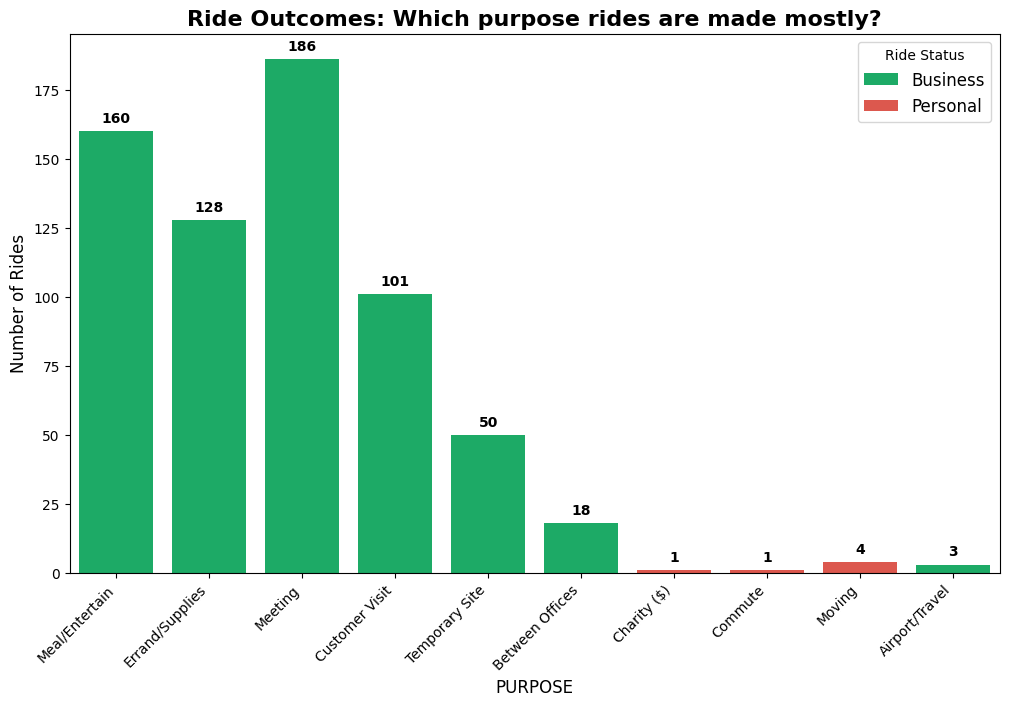

💡 KEY INSIGHT:
   Business    → HIGH Rides are made  (riders are prefers cab mostly for Meeting purpose)
   Personal → Low Rides are made (Riders mostly dont prefer cab for personal purpose)
   Two DIFFERENT problems needing two DIFFERENT solutions!


In [63]:
# ============================================================
# CHART 4: Seaborn Countplot — Purpose by Start Point
# ============================================================
# QUESTION: "Which location has most purpose missing? "
# KEY: sns.countplot counts AUTOMATICALLY — no groupby needed!

fig, ax= plt.subplots(figsize=(12,7))
sns.countplot(
    data=df,
    x='PURPOSE',
    hue='CATEGORY',
    palette=['#06C167', '#F44336'],
    ax=ax
)
# We passed RAW data. Seaborn did the counting!
# Matplotlib would have required: df.groupby(['Pickup point','Status']).size() first.

for container in ax.containers:
    ax.bar_label(container, padding=4, fontsize=10, fontweight='bold')
ax.set_title('Ride Outcomes: Which purpose rides are made mostly?',
             fontsize=16, fontweight='bold')
ax.set_xlabel('PURPOSE',fontsize=12)
ax.set_ylabel('Number of Rides', fontsize=12)
ax.legend(title='Ride Status', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout
plt.show()


print("💡 KEY INSIGHT:")
print("   Business    → HIGH Rides are made  (riders are prefers cab mostly for Meeting purpose)")
print("   Personal → Low Rides are made (Riders mostly dont prefer cab for personal purpose)")
print("   Two DIFFERENT problems needing two DIFFERENT solutions!")

/tmp/ipykernel_1261/1776045577.py:26: UserWarning: Glyph 128748 (\N{AIRPLANE ARRIVING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128748 (\N{AIRPLANE ARRIVING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


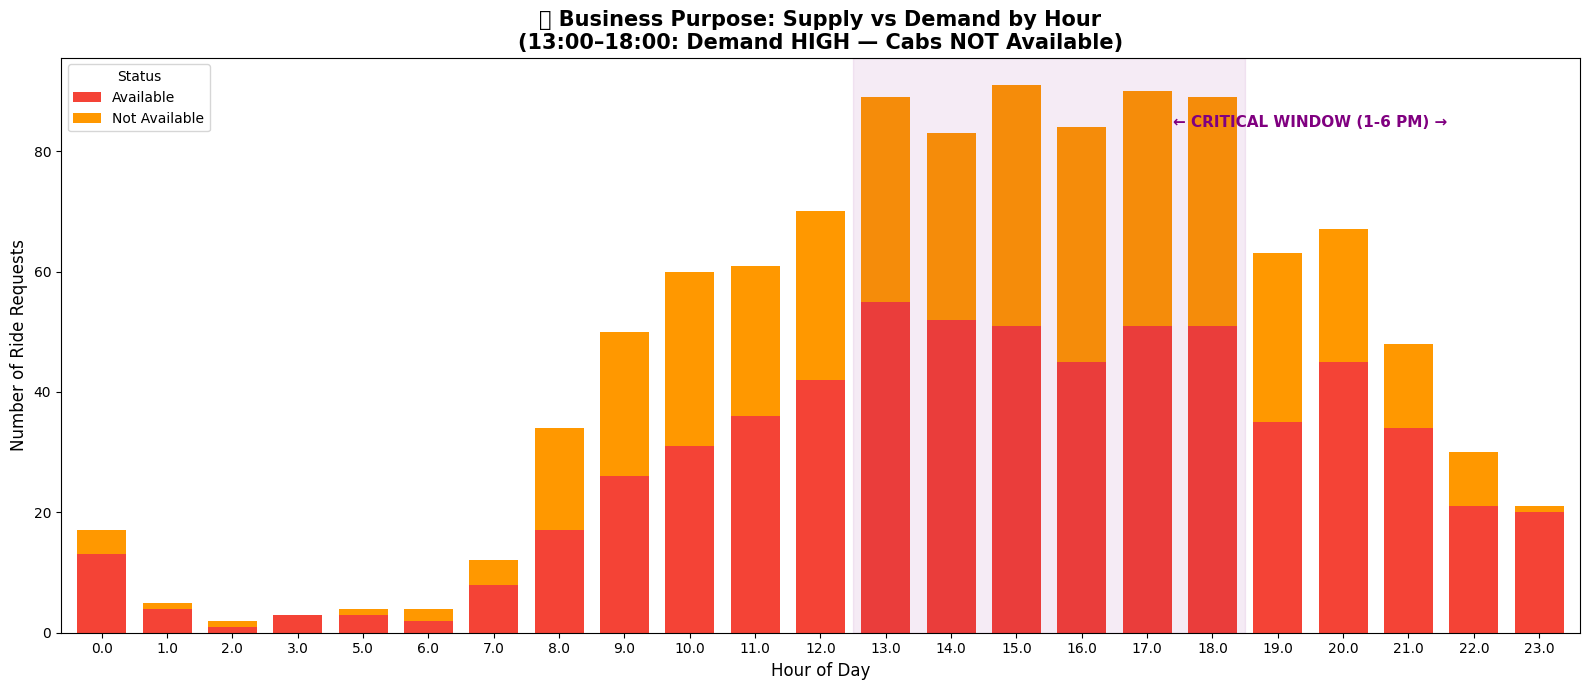

In [64]:
# ============================================================
# CHART 5: Stacked Bar — Airport → City Demand-Supply Gap
# ============================================================
# QUESTION: "When is the Airport→City gap worst?"

business_hourly=df[df['CATEGORY'] == 'Business'].groupby(
    ['start_hr', 'purpose_availability']
).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(16,7))
business_hourly.plot(
    kind='bar', stacked=True,
    color=['#F44336', '#FF9800', '#06C167'],
    ax=ax, width=0.75
)
ax.axvspan(11.5, 17.5, alpha=0.08, color='purple')
ax.text(18.5, ax.get_ylim()[1] * 0.88, '← CRITICAL WINDOW (1-6 PM) →',
        ha='center', color='purple', fontweight='bold', fontsize=11)

ax.set_title('🛬 Business Purpose: Supply vs Demand by Hour\n'
             '(13:00–18:00: Demand HIGH — Cabs NOT Available)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Number of Ride Requests', fontsize=12)
ax.legend(title='Status', fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [65]:
grouped=df[df['CATEGORY'] == 'Business'].groupby(['start_hr','purpose_availability']).agg({'CATEGORY': 'count'}).reset_index()
print(grouped)

    start_hr purpose_availability  CATEGORY
0        0.0            Available        13
1        0.0        Not Available         4
2        1.0            Available         4
3        1.0        Not Available         1
4        2.0            Available         1
5        2.0        Not Available         1
6        3.0            Available         3
7        5.0            Available         3
8        5.0        Not Available         1
9        6.0            Available         2
10       6.0        Not Available         2
11       7.0            Available         8
12       7.0        Not Available         4
13       8.0            Available        17
14       8.0        Not Available        17
15       9.0            Available        26
16       9.0        Not Available        24
17      10.0            Available        31
18      10.0        Not Available        29
19      11.0            Available        36
20      11.0        Not Available        25
21      12.0            Availabl

/tmp/ipykernel_1261/1399554955.py:25: UserWarning: Glyph 128748 (\N{AIRPLANE ARRIVING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128748 (\N{AIRPLANE ARRIVING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


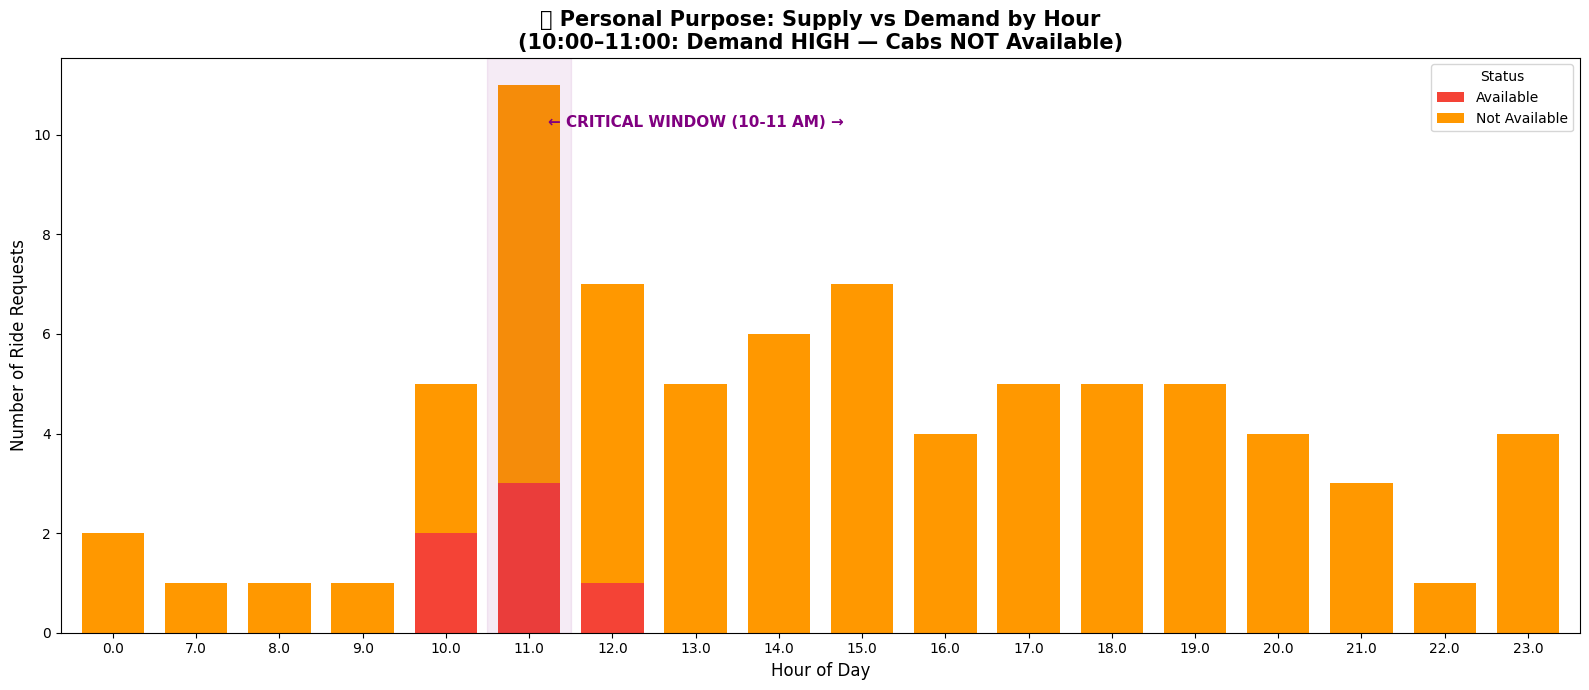

In [66]:
# ============================================================
# CHART 6: Stacked Bar — City → Airport Demand-Supply Gap
# ============================================================

personal_hourly=df[df['CATEGORY'] == 'Personal'].groupby(
    ['start_hr', 'purpose_availability']
).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(16,7))
personal_hourly.plot(
    kind='bar', stacked=True,
    color=['#F44336', '#FF9800', '#06C167'],
    ax=ax, width=0.75
)
ax.axvspan(4.5, 5.5, alpha=0.08, color='purple')
ax.text(7, ax.get_ylim()[1] * 0.88, '← CRITICAL WINDOW (10-11 AM) →',
        ha='center', color='purple', fontweight='bold', fontsize=11)

ax.set_title('🛬 Personal Purpose: Supply vs Demand by Hour\n'
             '(10:00–11:00: Demand HIGH — Cabs NOT Available)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Number of Ride Requests', fontsize=12)
ax.legend(title='Status', fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1261/704238763.py:34: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


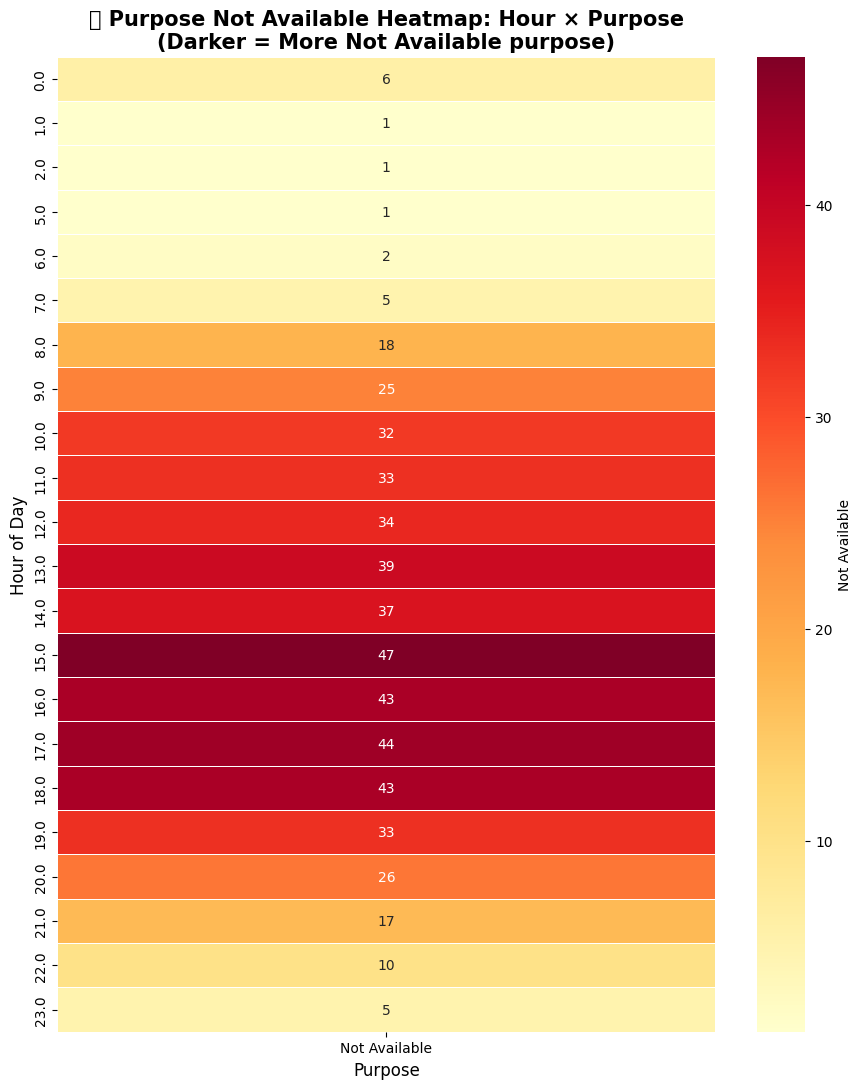

In [67]:
# ============================================================
# CHART 7: Heatmap — Purposes by Hour & Category
# ============================================================
# A HEATMAP is a colour-coded table.
# Dark = many. Light = few. Best for 2D pattern detection.
#
# Hour  | City  | Airport
# ──────┼───────┼─────────
#  5 AM │ DARK  │  light   ← City: many cancellations at 5 AM
#  2 PM │ light │  light   ← quiet in the afternoon
#  8 PM │ light │  DARK    ← Airport: No Cars in the evening

purpose_nt_avail=df[df['purpose_availability']=='Not Available']

heatmap_data=purpose_nt_avail.groupby(
    ['start_hr','purpose_availability']
    ).size().unstack(fill_value=0)
##print(purpose_nt_avail)

fig, ax=plt.subplots(figsize=(9,11))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='d',
    cmap='YlOrRd',
    linewidth=0.5,
    ax=ax,
    cbar_kws={'label': 'Not Available'}
)
ax.set_title('🔥 Purpose Not Available Heatmap: Hour × Purpose\n'
             '(Darker = More Not Available purpose)',
            fontsize=15, fontweight='bold')
ax.set_xlabel('Purpose', fontsize=12)
ax.set_ylabel('Hour of Day', fontsize=12)
plt.tight_layout()
plt.show()

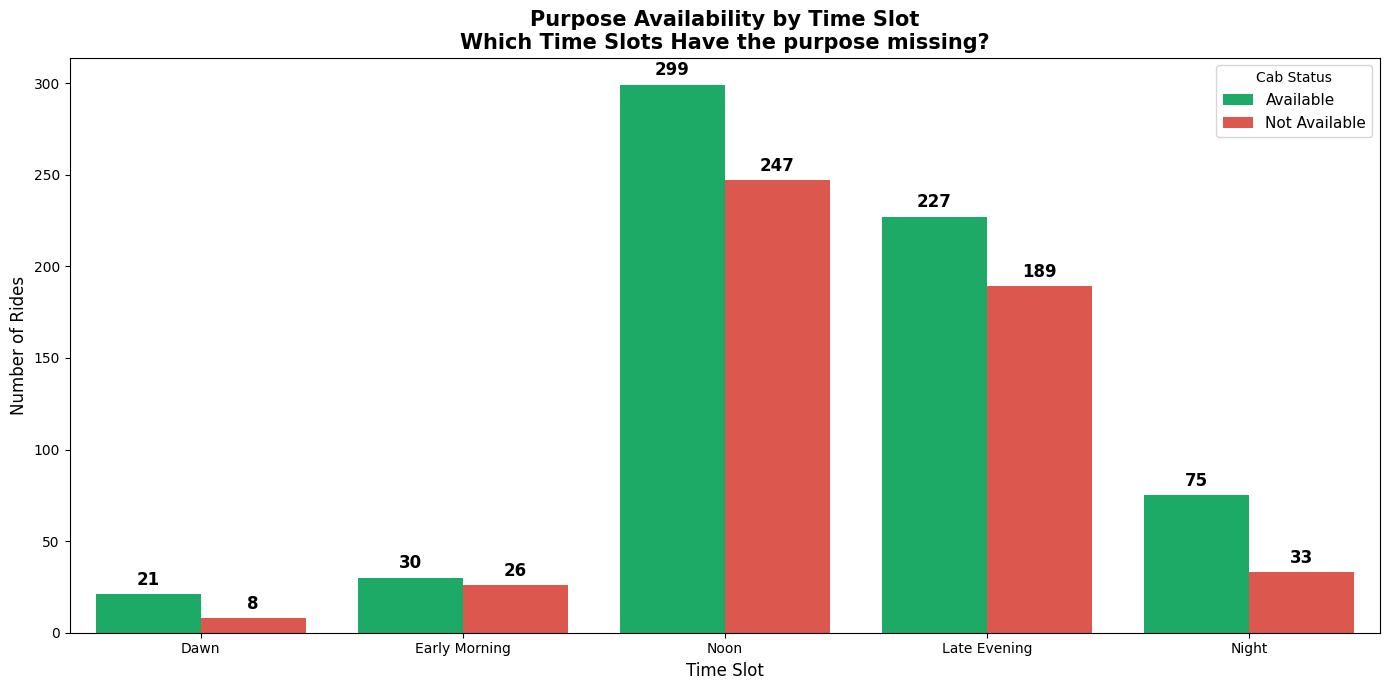

In [68]:
# ============================================================
# CHART 9: Countplot — Purpose Availability by Time Slot
# ============================================================
# QUESTION: "Which time slot has the worst gap?"

timeslot_order = ['Dawn','Early Morning','Noon','Late Evening','Night']

fig, ax= plt.subplots(figsize=(14,7))
sns.countplot(
    data=df,
    x='TimeSlot',
    hue='purpose_availability',
    palette=['#06C167', '#F44336'],
    order=timeslot_order,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, padding=4, fontsize=12, fontweight='bold')

ax.set_title('Purpose Availability by Time Slot\n'
             'Which Time Slots Have the purpose missing?',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Time Slot',fontsize=12)
ax.set_ylabel('Number of Rides',fontsize=12)
ax.legend(title='Cab Status', fontsize=11)
plt.tight_layout()
plt.show()

In [69]:
##GroupBy & Aggregation: Pivot Tables in Python

##df.groupby('category')['value_column'].aggregation()

# ============================================================
# GROUPBY 1: Rides per Pickup Point
# ============================================================

rides_by_pickup = df.groupby('START').size()
print("Rides per pick up point:")
print(rides_by_pickup.head(10))

print("Rides by Pickup up point x Status (Pivot table): ")
rides_pivot = df.groupby(['START','purpose_availability']).size().unstack(fill_value=0)
#                .unstack() turns Status into column headers — just like an Excel pivot!
print(rides_pivot.head(20))

Rides per pick up point:
START
Agnew                         4
Almond                        1
Apex                         17
Arabi                         1
Arlington                     1
Arlington Park at Amberly     1
Asheville                     2
Austin                        1
Banner Elk                    8
Bellevue                      1
dtype: int64
Rides by Pickup up point x Status (Pivot table): 
purpose_availability       Available  Not Available
START                                              
Agnew                              0              4
Almond                             0              1
Apex                              11              6
Arabi                              1              0
Arlington                          0              1
Arlington Park at Amberly          0              1
Asheville                          1              1
Austin                             1              0
Banner Elk                         2              6
Bellevue      

In [70]:
# ============================================================
# GROUPBY 2: Not Available Rate per Category
# ============================================================

print("Not Available Rates per category")
print()
for cat in ['Business','Personal']:
    ##print(cat)
    subset=df[df['CATEGORY']== cat ]
    notavail_count = (subset['purpose_availability'] == 'Not Available').sum()
    total = len(subset)
    ##print(notavail_count)
    ##print(total)
    print(f" {cat}: n={total:,}")
    print(f" Not Available Rate: {notavail_count/total*100:.1f}%")
    print(f" Completion Rate: {(1-(notavail_count)/total)*100:.1f}%")
print()

Not Available Rates per category

 Business: n=1,077
 Not Available Rate: 40.0%
 Completion Rate: 60.0%
 Personal: n=77
 Not Available Rate: 92.2%
 Completion Rate: 7.8%



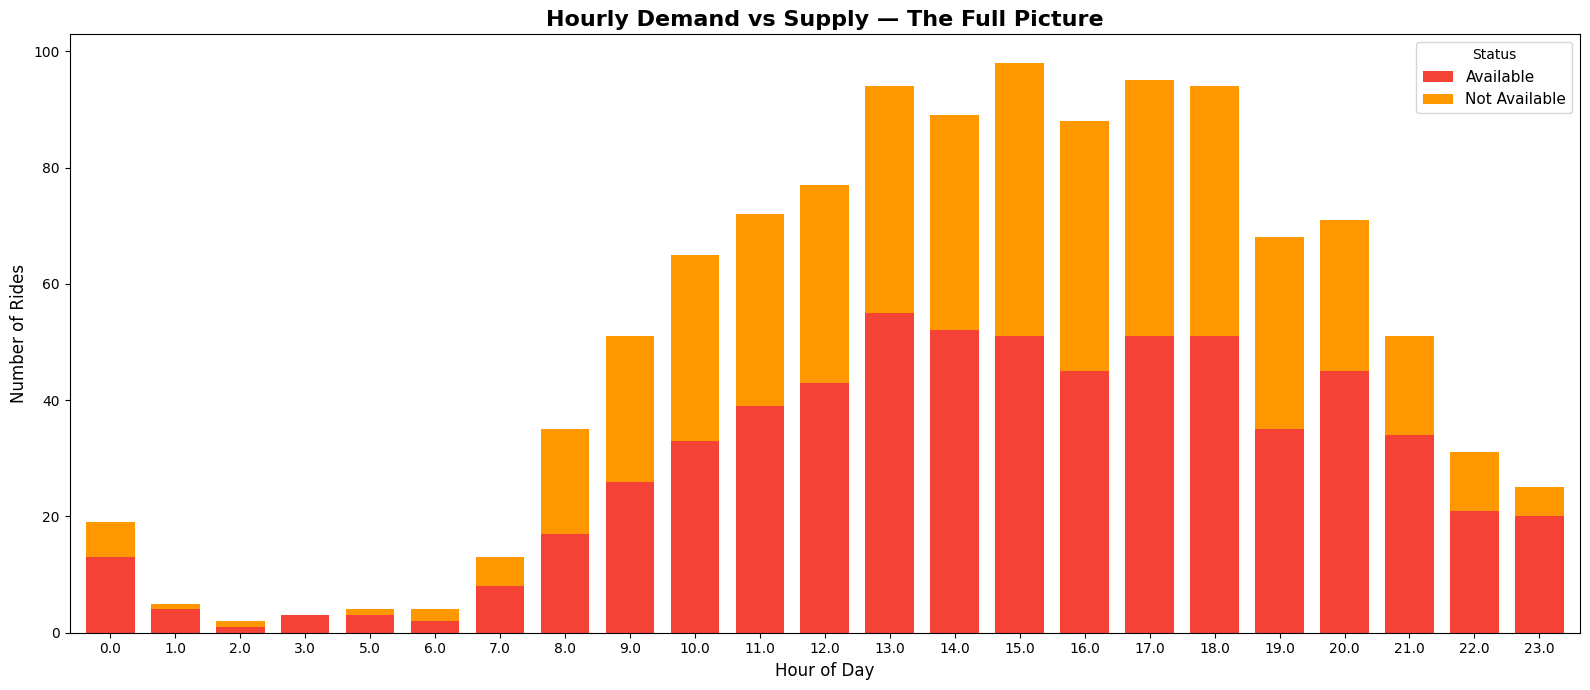

In [71]:
# ============================================================
# GROUPBY 4: Hourly Supply-Demand Gap — Full Picture
# ============================================================

hourly_status = df.groupby(['start_hr','purpose_availability']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16,7))
hourly_status.plot(
    kind='bar', stacked=True,
    color=['#F44336', '#FF9800', '#06C167'],
    ax=ax, width=0.75
)

ax.set_title('Hourly Demand vs Supply — The Full Picture', fontsize=16, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Number of Rides', fontsize=12)
ax.legend(title='Status',fontsize=11)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [72]:
# ============================================================
# 🏋️ EXERCISE WORKSPACE
# ============================================================

# Exercise 1 — NumPy

driver_ratings = np.array([4.2, 3.8, 4.9, 2.1, 4.7, 3.5, 4.4, 4.0, 2.8, 4.6])
print("=== EXERCISE 1: NumPy ===")
print("Mean    :", driver_ratings.mean())
print(f"Mean   : {np.mean(driver_ratings):.2f}")
print(f"Median  : {np.median(driver_ratings):.2f}")
print(f"Min Driver ratings  : {np.min(driver_ratings):.2f}")
print(f"Max Driver ratings  : {np.max(driver_ratings):.2f}")
print(f"Driver ratings above 4  : {np.sum(driver_ratings > 4.0):} drivers")
print(f"Driver ratings below 3.5  : {np.sum(driver_ratings < 3.5):} drivers")
print(f"Boost ratings by 0.3  : {np.round(driver_ratings + 0.3 , 2)} ")

print()
print("=== EXERCISE 2: Pandas Filtering ===")
no_purpose = df[df['purpose_availability']=='Not Available']
business_nt_availpurpose = df[(df['CATEGORY']=='Business') & (df['purpose_availability']=='Not Available')]
night_rides=df[df['TimeSlot']=='Night']
##night_rate=(night_rides['PURPOSE']=='Available').mean()*100
night_ride_count=((df['TimeSlot']=='Night').sum())
total_count=len(df)

print(f"Purpose Not Available  : {len(no_purpose):,}")
print(f"Business Purpose Not Available  : {len(business_nt_availpurpose):,}")
print(f"Night Rides Rate  : {night_ride_count/total_count*100:.2f}")
print()

print("=== EXERCISE 3: GroupBy ===")

##Group by TimeSlot and count rides per slot
timeslot_count=df.groupby('TimeSlot').size().sort_values(ascending=True)
print("Group by TimeSlot and count rides per slot")
print(timeslot_count)

##Create a crosstab of Pickup point × TimeSlot
crosstab_cnt=pd.crosstab(df['START'], df['TimeSlot'])
print(crosstab_cnt.head(20))

##Which location has a higher cancellation rate during Early Morning?
not_avail=df[(df['purpose_availability']=='Not Available') & (df['TimeSlot']=='Early Morning')]
not_avail_rate=not_avail.groupby('START').size().sort_values(ascending=False)
print(not_avail_rate)
##print(not_avail_rate[not_avail_rate['START'] == not_avail_rate['START'].max()])
##not_avail_rate['START'].idxmax()

=== EXERCISE 1: NumPy ===
Mean    : 3.9
Mean   : 3.90
Median  : 4.10
Min Driver ratings  : 2.10
Max Driver ratings  : 4.90
Driver ratings above 4  : 5 drivers
Driver ratings below 3.5  : 2 drivers
Boost ratings by 0.3  : [4.5 4.1 5.2 2.4 5.  3.8 4.7 4.3 3.1 4.9] 

=== EXERCISE 2: Pandas Filtering ===
Purpose Not Available  : 503
Business Purpose Not Available  : 431
Night Rides Rate  : 9.35

=== EXERCISE 3: GroupBy ===
Group by TimeSlot and count rides per slot
TimeSlot
Dawn              29
Early Morning     56
Night            108
Late Evening     416
Noon             546
dtype: int64
TimeSlot                   Dawn  Early Morning  Late Evening  Night  Noon
START                                                                    
Agnew                         0              1             1      1     1
Almond                        0              0             0      0     1
Apex                          0              0             8      3     6
Arabi                         0      

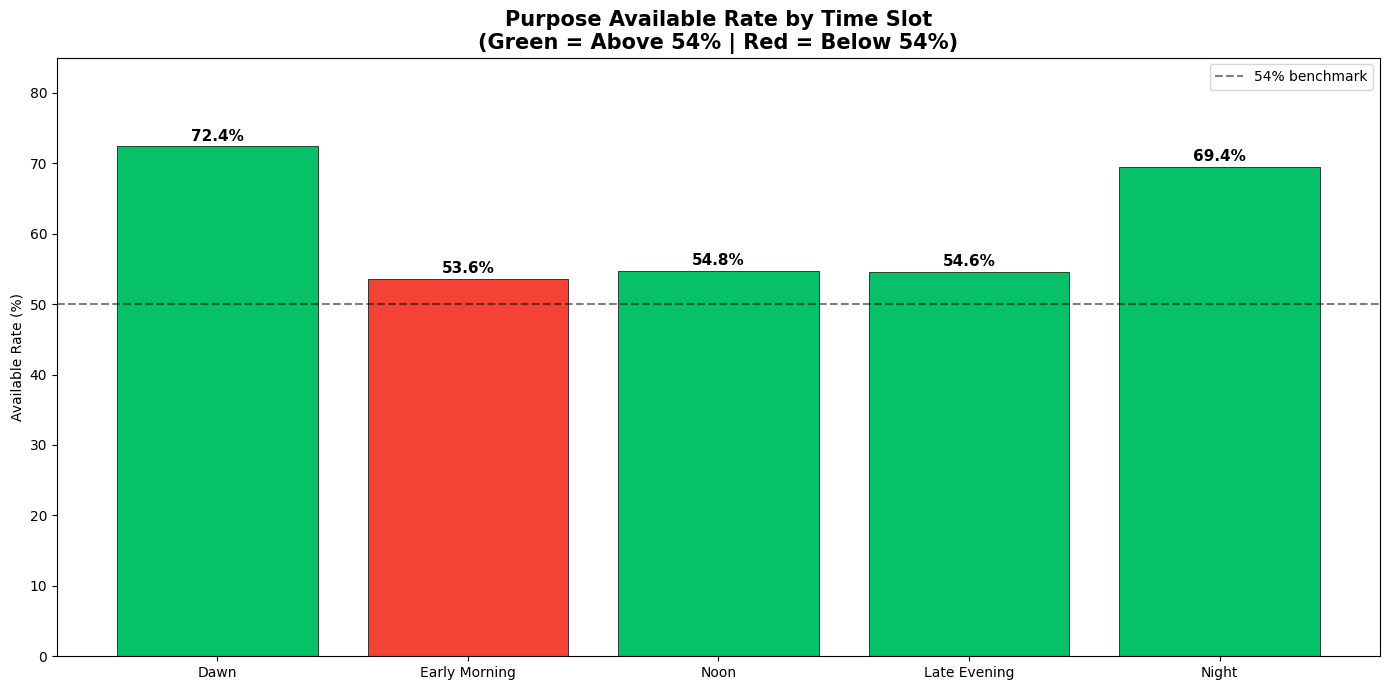

In [73]:
# ============================================================
# EXERCISE 4: Completion Rate by Time Slot (Visualisation)
# ============================================================

timeslot_order = ['Dawn','Early Morning','Noon','Late Evening','Night']

timeslot_count=df['TimeSlot'].value_counts()
available_rate = (
    df.groupby('TimeSlot')['purpose_availability']
    .apply(lambda x: (x == 'Available').mean() * 100)
    .reindex(timeslot_order)
)


fig, ax = plt.subplots(figsize=(14,7))

bars = ax.bar(
    available_rate.index,
    available_rate.values,
    color=['#06C167' if r >= 54 else '#F44336' for r in available_rate.values],
    edgecolor='black', linewidth=0.5
)


ax.axhline(y=50, color='black', linestyle='--', alpha=0.5, label='54% benchmark')
for bar, val in zip(bars, available_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

ax.set_title('Purpose Available Rate by Time Slot\n'
             '(Green = Above 54% | Red = Below 54%)',
             fontsize=15, fontweight='bold')
ax.set_ylabel('Available Rate (%)')
ax.set_ylim(0, 85)
ax.legend()
plt.tight_layout()
plt.show()

In [74]:
# ============================================================
# BONUS: Save the enriched dataset
# ============================================================

df.to_excel('uber_enriched.xlsx', index=False)
print("💾 Enriched dataset saved as 'uber_enriched.xlsx'")
print(f"   New columns: start_hr, TimeSlot, purpose_availability")
print(f"   Total rows  : {len(df):,}")
print()
print("=" * 60)
print("🎉 CONGRATULATIONS! You have completed the Uber Data Analysis!")
print("=" * 60)
print("""
Key commands you now own:
  📦 import            → bring in tools
  📂 pd.read_excel()   → load data
  👀 df.head()         → always look first
  🔍 df.isnull()       → spot missing values
  🔧 .apply()          → create new columns
  📊 df.groupby()      → aggregate like pivot tables
  📈 plt.bar()         → draw bar charts
  🎨 sns.countplot()   → draw charts with less code
  🔥 sns.heatmap()     → spot 2D patterns at a glance
""")

💾 Enriched dataset saved as 'uber_enriched.xlsx'
   New columns: RequestHour, TimeSlot, Cab Availability
   Total rows  : 1,155

🎉 CONGRATULATIONS! You have completed the Uber Data Analysis!

Key commands you now own:
  📦 import            → bring in tools
  📂 pd.read_excel()   → load data
  👀 df.head()         → always look first
  🔍 df.isnull()       → spot missing values
  🔧 .apply()          → create new columns
  📊 df.groupby()      → aggregate like pivot tables
  📈 plt.bar()         → draw bar charts
  🎨 sns.countplot()   → draw charts with less code
  🔥 sns.heatmap()     → spot 2D patterns at a glance

